In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# carregar os dois resultados
df1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/results/uls_dynamic_summary_table.csv")
df2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks_Andressa_MMQ/mmq_msc_andressa/results/uls_selected_columns_table.csv")

# Ensure instance columns are consistent for merging/plotting
df1['Instance'] = df1['Instance'].str.split('.').str[0] # Remove '.csv' if present
df2['instance'] = df2['instance'].str.split('.').str[0] # Remove '.csv' if present

# Filter out rows where 'instance' does not contain '_' before sorting
df1_filtered = df1[df1['Instance'].str.contains('_')].copy()
df2_filtered = df2[df2['instance'].str.contains('_')].copy()


# Ordenar o DataFrame por 'Instância' usando uma chave personalizada para ordenar numericamente após o prefixo
df1_sorted = df1_filtered.copy()
df1_sorted['sort_key'] = df1_sorted['Instance'].apply(lambda x: int(x.split('_')[1]))
df1_sorted = df1_sorted.sort_values(by='sort_key').drop('sort_key', axis=1)

df2_sorted = df2_filtered.copy()
df2_sorted['sort_key'] = df2_sorted['instance'].apply(lambda x: int(x.split('_')[1]))
df2_sorted = df2_sorted.sort_values(by='sort_key').drop('sort_key', axis=1)


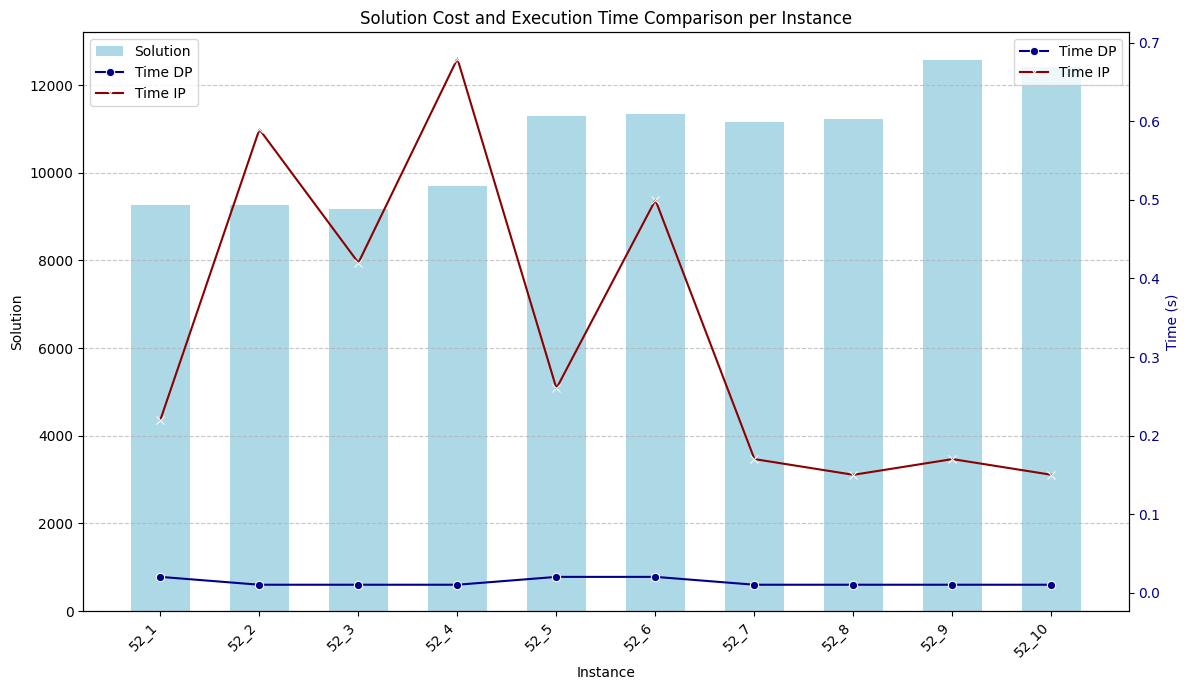

In [ ]:
# Renomear colunas antes de mesclar para garantir nomes distintos
df1_renamed = df1_sorted.rename(columns={'Solution': 'Solution_algDP', 'Time (s)': 'Time_algDP'})
df2_renamed = df2_sorted.rename(columns={'objval': 'Solution_algIP', 'time': 'Time_algIP', 'instance': 'Instance'})

# Mesclar os dois dataframes ordenados com base no nome da instância
merged_df = pd.merge(df1_renamed, df2_renamed, on='Instance')

# Criar figura e eixos para o gráfico
fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de barras para o valor da solução (apenas uma barra por instância)
bar_width = 0.6
instances = merged_df['Instance']
x = np.arange(len(instances))

# Como as soluções são iguais, podemos usar a solução de um dos algoritmos
bars = ax1.bar(x, merged_df['Solution_algDP'], bar_width, label='Solution', color='lightblue')


ax1.set_ylabel('Solution', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(instances, rotation=45, ha='right')
ax1.set_xlabel('Instance')


# Criar um eixo Y secundário para o Tempo
ax2 = ax1.twinx()

# Gráfico de linha para os valores de Tempo
sns.lineplot(data=merged_df, x=x, y='Time_algDP', ax=ax2, color='darkblue', marker='o', linestyle='-', label='Time DP')
sns.lineplot(data=merged_df, x=x, y='Time_algIP', ax=ax2, color='darkred', marker='x', linestyle='-', label='Time IP')


ax2.set_ylabel('Time (s)', color='darkblue') # Cor da label do eixo secundário
ax2.tick_params(axis='y', labelcolor='darkblue')


# Combinar legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Adicionar título e grade
plt.title('Solution Cost and Execution Time Comparison per Instance')
ax1.grid(axis='y', linestyle='--', alpha=0.7) # Grade no eixo primário
fig.tight_layout()

plt.show()

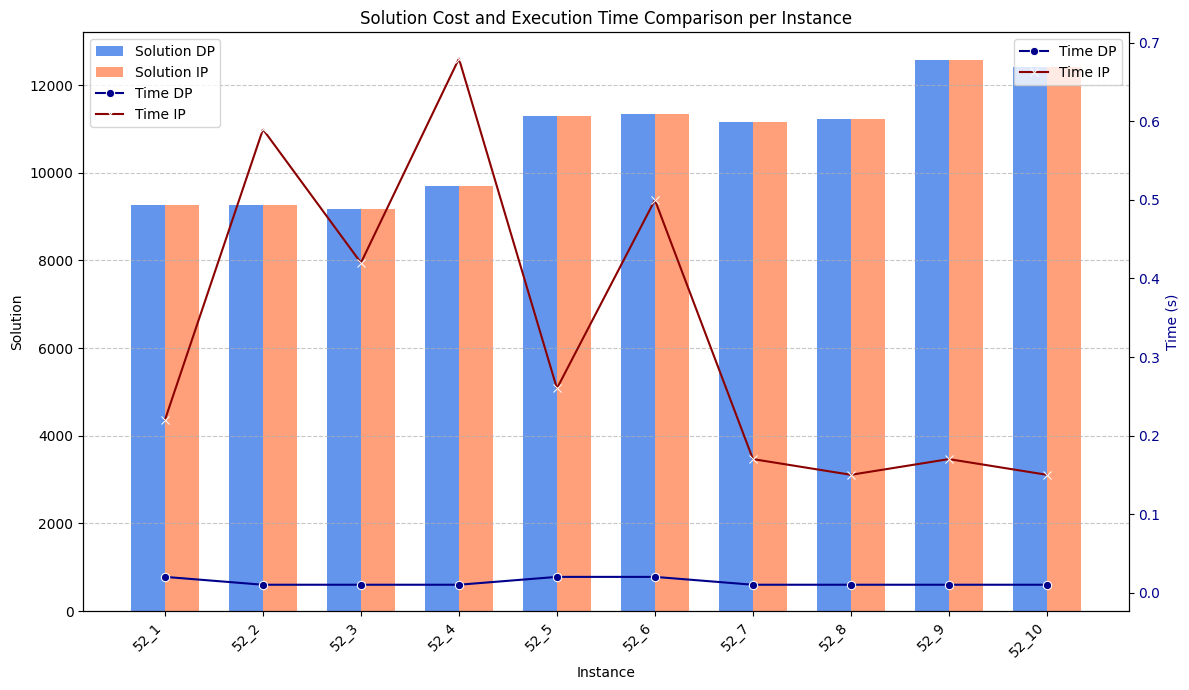

In [38]:
# Criar figura e eixos para o gráfico
fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de barras para o valor da solução (duas barras por instância)
bar_width = 0.35
instances = merged_df['Instance']
x = np.arange(len(instances))

bars1 = ax1.bar(x - bar_width/2, merged_df['Solution_algDP'], bar_width, label='Solution DP', color='cornflowerblue')
bars2 = ax1.bar(x + bar_width/2, merged_df['Solution_algIP'], bar_width, label='Solution IP', color='lightsalmon')


ax1.set_ylabel('Solution', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(instances, rotation=45, ha='right')
ax1.set_xlabel('Instance')


# Criar um eixo Y secundário para o Tempo
ax2 = ax1.twinx()

# Gráfico de linha para os valores de Tempo
sns.lineplot(data=merged_df, x=x, y='Time_algDP', ax=ax2, color='darkblue', marker='o', linestyle='-', label='Time DP')
sns.lineplot(data=merged_df, x=x, y='Time_algIP', ax=ax2, color='darkred', marker='x', linestyle='-', label='Time IP')


ax2.set_ylabel('Time (s)', color='darkblue') # Cor da label do eixo secundário
ax2.tick_params(axis='y', labelcolor='darkblue')


# Combinar legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Adicionar título e grade
plt.title('Solution Cost and Execution Time Comparison per Instance')
ax1.grid(axis='y', linestyle='--', alpha=0.7) # Grade no eixo primário
fig.tight_layout()

plt.show()